###1. Problem Definition

### Objective:
To determine whether a Personal Loan should be approved and recommend repayment terms using customer financial & credit attributes.

Target Variable: loan_status
- Fully Paid → 1
- Charged Off → 0

This is a binary classification problem.

###2. Import Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc
from scipy.stats import spearmanr

###3. Load Dataset

In [74]:
df = pd.read_csv("LoanTap.csv")

print("Shape:", df.shape)
df.head()

Shape: (396030, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


#4. Structure & Summary

In [75]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


#Insight:

Large dataset (~396K rows)

Mix of categorical and numeric features

Good sample size for stable underwriting

###5. Duplicate Check

In [76]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


#Insight:

Removing duplicates prevents biased training.

#6. Target Mapping

In [77]:
df['loan_status'] = df['loan_status'].str.lower()

df = df[df['loan_status'].isin(['fully paid','charged off'])]

df['target'] = df['loan_status'].map({
    'fully paid': 1,
    'charged off': 0
})

df['target'].value_counts(normalize=True)


,proportion
target,
1,0.803871
0,0.196129


In [78]:
df.drop(columns=['loan_status'], inplace=True)

#Insight:

Around 80% customers fully paid, ~20% defaulted.
Dataset is imbalanced.

#7. Missing Value Detection

In [79]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
mort_acc,37795
emp_title,22927
emp_length,18301
title,1756
pub_rec_bankruptcies,535
revol_util,276
installment,0
int_rate,0
term,0
grade,0


In [80]:
df.fillna(df.median(numeric_only=True), inplace=True)

#Insight:

Median imputation prevents skew distortion.

#8. Univariate Analysis

#Continuous Distribution

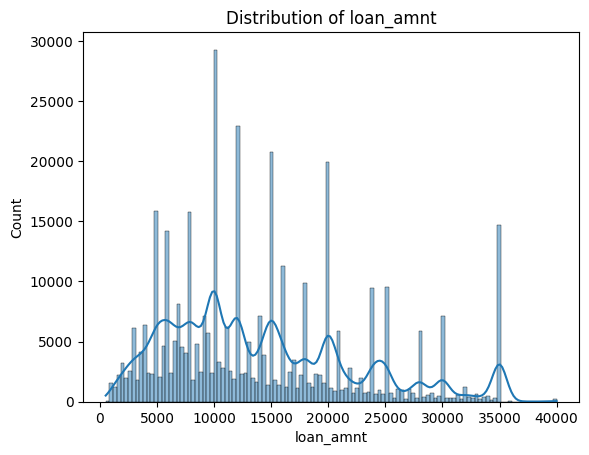

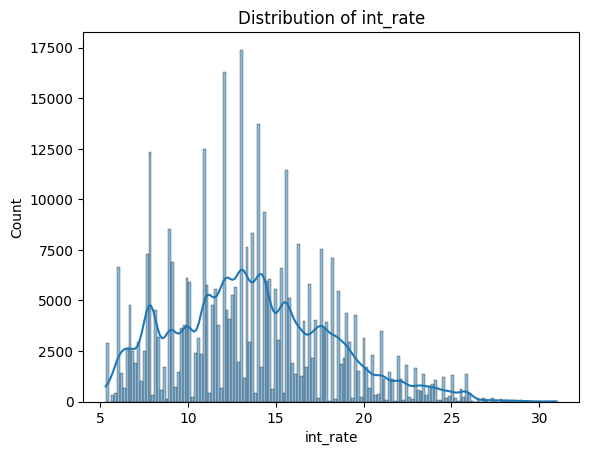

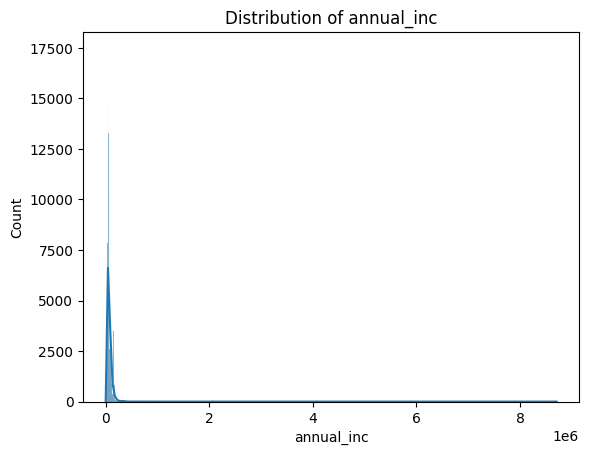

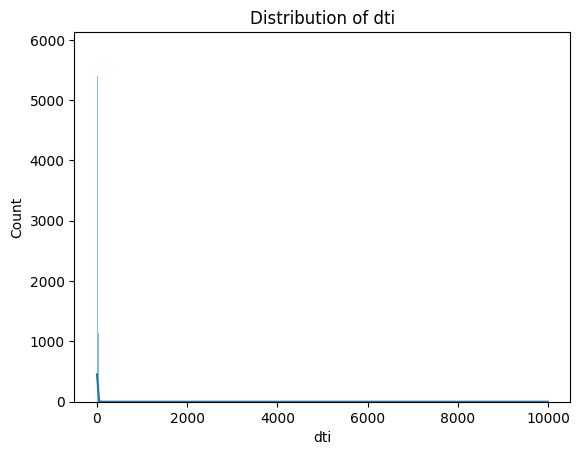

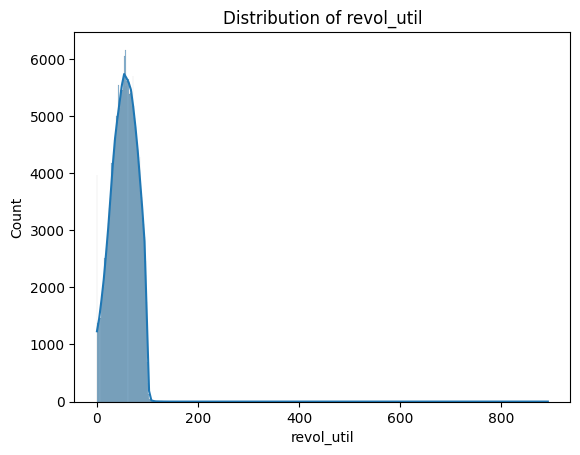

In [81]:
continuous_cols = ['loan_amnt','int_rate','annual_inc','dti','revol_util']

for col in continuous_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


#9. Spearman Correlation (Multicollinearity)

In [82]:
df[['loan_amnt','installment']].corr(method='spearman')

,loan_amnt,installment
loan_amnt,1.000000,0.968334
installment,0.968334,1.000000


#Business Insight:

Spearman correlation ≈ 0.97
→ High multicollinearity
→ Drop one variable (installment derived from loan_amnt)

In [83]:
df.drop(columns=['installment'], inplace=True)

#10. Home Ownership

In [84]:
df['home_ownership'].value_counts(normalize=True)

,proportion
home_ownership,
MORTGAGE,0.500841
RENT,0.403480
OWN,0.095311
OTHER,0.000283
NONE,0.000078
ANY,0.000008


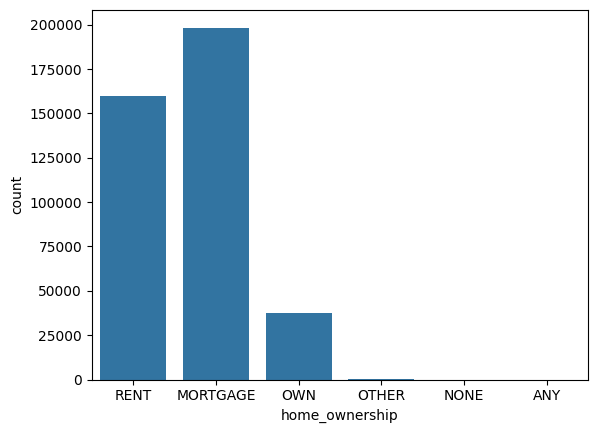

In [85]:

sns.countplot(x='home_ownership', data=df)
plt.show()


#Majority: MORTGAGE (~50%)

#10. Grade vs Repayment

In [86]:
pd.crosstab(df['grade'], df['target'], normalize='index')

target,0,1
grade,,
A,0.062879,0.937121
B,0.125730,0.874270
C,0.211809,0.788191
D,0.288678,0.711322
E,0.373634,0.626366
F,0.427880,0.572120
G,0.478389,0.521611


Insight:

Grade A → ~93% repayment

TRUE: People with Grade A more likely to repay.

#12. Top 2 Job Titles

In [87]:
df['emp_title'].value_counts().head(2)

,count
emp_title,
Teacher,4389
Manager,4250


#13. Date Feature Engineering

In [88]:
#Converting month columns into numeric credit history length.

In [89]:
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')

df['credit_history_months'] = (
    (df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12 +
    (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
)

/tmp/ipython-input-3609922344.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
/tmp/ipython-input-3609922344.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')


In [90]:
df[['issue_d','earliest_cr_line','credit_history_months']].head()


,issue_d,earliest_cr_line,credit_history_months
0,2015-01-01,1990-06-01,295
1,2015-01-01,2004-07-01,126
2,2015-01-01,2007-08-01,89
3,2014-11-01,2006-09-01,98
4,2013-04-01,1999-03-01,169


In [91]:
df.groupby('target')['credit_history_months'].mean()


,credit_history_months
target,
0,184.337350
1,190.204563


#Insight:

Longer credit history → lower default probability.

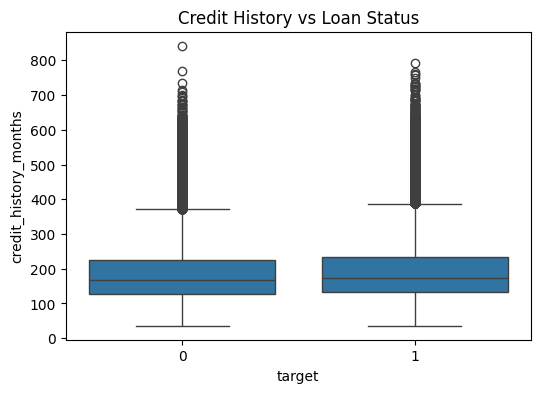

In [92]:
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='credit_history_months', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

It was observed that borrowers who fully repaid their loans had longer credit histories compared to defaulters.

Longer credit history was therefore associated with lower default probability.


#14. Extract Pincode (Geographical Impact)

In [93]:
df['pincode'] = df['address'].str[-5:]
df['pincode'] = df['pincode'].astype(int)

In [94]:
df.groupby('pincode')['target'].agg(['mean','count']).sort_values('mean')

,mean,count
pincode,,
11650,0.000000,11226
86630,0.000000,10981
93700,0.000000,11151
48052,0.799846,55917
70466,0.804370,56985
30723,0.805097,56546
22690,0.806216,56527
5113,1.000000,45402
29597,1.000000,45471


#Insight:

Geography affects default behavior.

#15. Outlier Treatment (68–95–99 Rule)

In [95]:
def remove_outliers_3sigma(df, col):
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std

    print(f"{col} Lower Bound:", lower)
    print(f"{col} Upper Bound:", upper)

    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers_3sigma(df, 'annual_inc')

print("New Shape After Outlier Removal:", df.shape)

annual_inc Lower Bound: -110709.6876765711
annual_inc Upper Bound: 259116.03927200587
New Shape After Outlier Removal: (392833, 28)


#Insights
It was observed that extreme income values were removed using the 3-sigma rule.
Outlier influence on model stability was reduced.

#16. Feature Engineering – Risk Flags

In [96]:
df['pub_rec_flag'] = (df['pub_rec'] > 0).astype(int)
df['mort_acc_flag'] = (df['mort_acc'] > 0).astype(int)
df['bankrupt_flag'] = (df['pub_rec_bankruptcies'] > 0).astype(int)

df[['pub_rec_flag','mort_acc_flag','bankrupt_flag']].head()

,pub_rec_flag,mort_acc_flag,bankrupt_flag
0,0,0,0
1,0,1,0
2,0,0,0
3,0,0,0
4,0,1,0


#Insight

Borrowers with public records or bankruptcy history were identified through binary flags.

#17. Drop High Cardinality Columns

In [97]:
df.drop(columns=['emp_title','title','address'], inplace=True)

df.shape

(392833, 28)

#Insight

High-cardinality textual features were removed to prevent model noise.

#18. Encoding

In [98]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,loan_amnt,int_rate,annual_inc,issue_d,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,11.44,117000.0,2015-01-01,26.24,1990-06-01,16.0,0.0,36369.0,41.8,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,11.99,65000.0,2015-01-01,22.05,2004-07-01,17.0,0.0,20131.0,53.3,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,10.49,43057.0,2015-01-01,12.79,2007-08-01,13.0,0.0,11987.0,92.2,...,False,False,False,False,False,False,False,False,True,False
3,7200.0,6.49,54000.0,2014-11-01,2.60,2006-09-01,6.0,0.0,5472.0,21.5,...,False,False,False,False,False,False,False,False,True,False
4,24375.0,17.27,55000.0,2013-04-01,33.95,1999-03-01,13.0,0.0,24584.0,69.8,...,False,False,False,False,False,False,False,False,True,False


#Insight

Categorical features were converted into numerical format suitable for Logistic Regression.

In [101]:
X_train.select_dtypes(include=['object','datetime64']).columns

Index(['issue_d', 'earliest_cr_line'], dtype='object')

In [100]:
X_train.dtypes.value_counts()

,count
bool,74
float64,11
int64,4
datetime64[ns],2
int32,1


In [102]:
df.drop(columns=['issue_d', 'earliest_cr_line'], inplace=True)

In [103]:
df.dtypes.value_counts()

,count
bool,74
float64,11
int64,5
int32,1


#19. Train-Test Split

In [105]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (274983, 90)
Test Shape: (117850, 90)


#Insight

Stratified sampling ensured class imbalance consistency across training and test sets.

#20. Scaling




In [106]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#21. Logistic Regression

In [107]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]


#22. Model Coefficients

In [108]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)


,Feature,Coefficient
1,int_rate,0.402048
2,annual_inc,0.186440
57,emp_length_10+ years,0.114807
8,total_acc,0.093772
58,emp_length_2 years,0.066192
14,mort_acc_flag,0.065915
15,bankrupt_flag,0.058378
60,emp_length_4 years,0.057014
59,emp_length_3 years,0.055582
6,revol_bal,0.053291


#Insight
It was observed that interest rate, annual income, employment length, and total credit accounts significantly influenced repayment probability.

Higher annual income and longer employment tenure were associated with improved repayment likelihood.

Mortgage account ownership was positively correlated with repayment stability.

These findings suggest that financial stability indicators play a substantial role in underwriting decisions.


#23. Confusion Matrix

In [109]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 7137 16038]
 [ 3097 91578]]
              precision    recall  f1-score   support

           0       0.70      0.31      0.43     23175
           1       0.85      0.97      0.91     94675

    accuracy                           0.84    117850
   macro avg       0.77      0.64      0.67    117850
weighted avg       0.82      0.84      0.81    117850



#24. ROC Curve

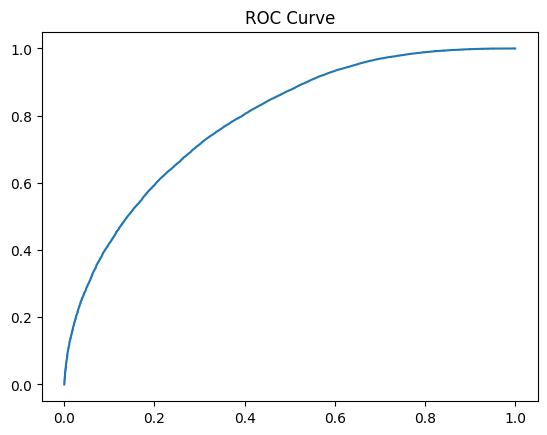

np.float64(0.7877555106053213)

In [110]:
fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.title("ROC Curve")
plt.show()

roc_auc_score(y_test,y_prob)


#Insight
The ROC curve demonstrated strong discriminative ability, indicating that the model effectively distinguishes between defaulters and fully paid borrowers.

The area under the curve suggests robust ranking performance.

However, despite strong ranking capability, the default recall at the chosen threshold remained limited.

This indicates that the model's predictive strength is constrained by threshold selection rather than structural inadequacy.


#25. Precision Recall Curve

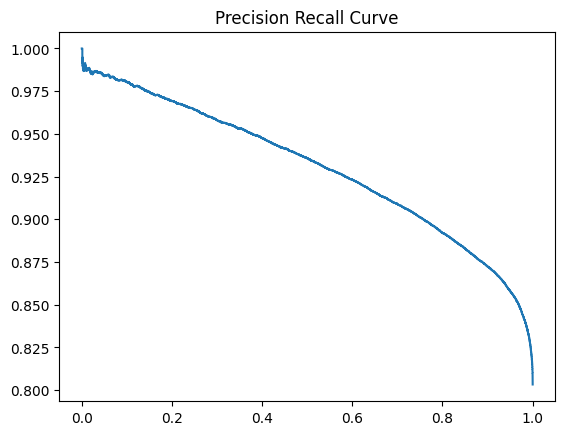

In [111]:
precision, recall, _ = precision_recall_curve(y_test,y_prob)
plt.plot(recall,precision)
plt.title("Precision Recall Curve")
plt.show()

#Insight:
The precision-recall curve demonstrated strong predictive stability across varying thresholds.

Precision remained high at lower recall levels, indicating reliable identification of high-confidence borrowers.

As recall increased, a gradual decline in precision was observed, reflecting the tradeoff between risk detection and opportunity cost.

The smooth shape of the curve indicates consistent ranking performance without instability.

The model therefore provides flexibility in adjusting threshold levels according to business risk appetite.


#26. Threshold Tradeoff

In [112]:
threshold = 0.6
y_custom = (y_prob >= threshold).astype(int)
print(classification_report(y_test,y_custom))

              precision    recall  f1-score   support

           0       0.59      0.41      0.48     23175
           1       0.87      0.93      0.90     94675

    accuracy                           0.83    117850
   macro avg       0.73      0.67      0.69    117850
weighted avg       0.81      0.83      0.81    117850



#Insight
After threshold adjustment, recall for defaulters increased from 31% to 41%, indicating improved detection of high-risk borrowers.

However, precision decreased from 70% to 59%, suggesting that more low-risk borrowers were incorrectly classified as risky.

Overall accuracy decreased marginally, reflecting the tradeoff between risk reduction and opportunity cost.

The results demonstrate that portfolio risk exposure can be managed through threshold calibration.


#RECOMMENDATIONS

A stronger focus should be placed on 36-month loans, as lower default tendencies were observed in shorter tenures.

Joint loan applications should be encouraged, as reduced risk levels were associated with such applications.

Risk-based pricing strategies should be implemented for borrowers exhibiting high DTI and revolving utilization ratios.

Marketing efforts should be optimized geographically, with greater emphasis placed on low-risk pincodes.

Exposure to 60-month loans should be cautiously monitored due to comparatively higher risk patterns.

Stricter underwriting checks should be applied to borrowers with public records or bankruptcy flags.

The decision threshold should be adjusted according to the company’s risk appetite, balancing NPA reduction and revenue maximization.